In [112]:
import importlib
import pandas as pd
from itables import show
from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
from src.A_Data_analysis import productivity_analysis
importlib.reload(fleet_analysis)
importlib.reload(assignment_analysis)
importlib.reload(productivity_analysis)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']
['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']


<module 'src.A_Data_analysis.productivity_analysis' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\A_Data_analysis\\productivity_analysis.py'>

# Fleet model

In [7]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final_analysis.xlsx')
### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Type':'Aircraft Type','Date':'Event Date'})


## Data analysis

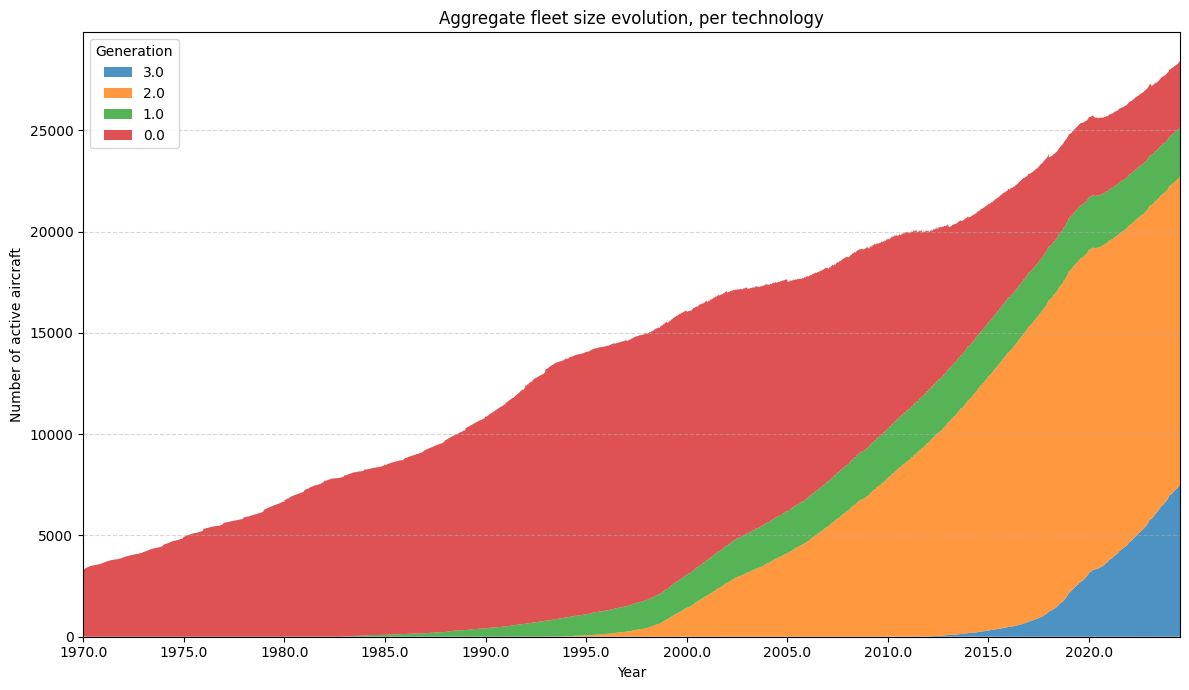

In [58]:
fleet_analysis.visu_fleet(db_selec)

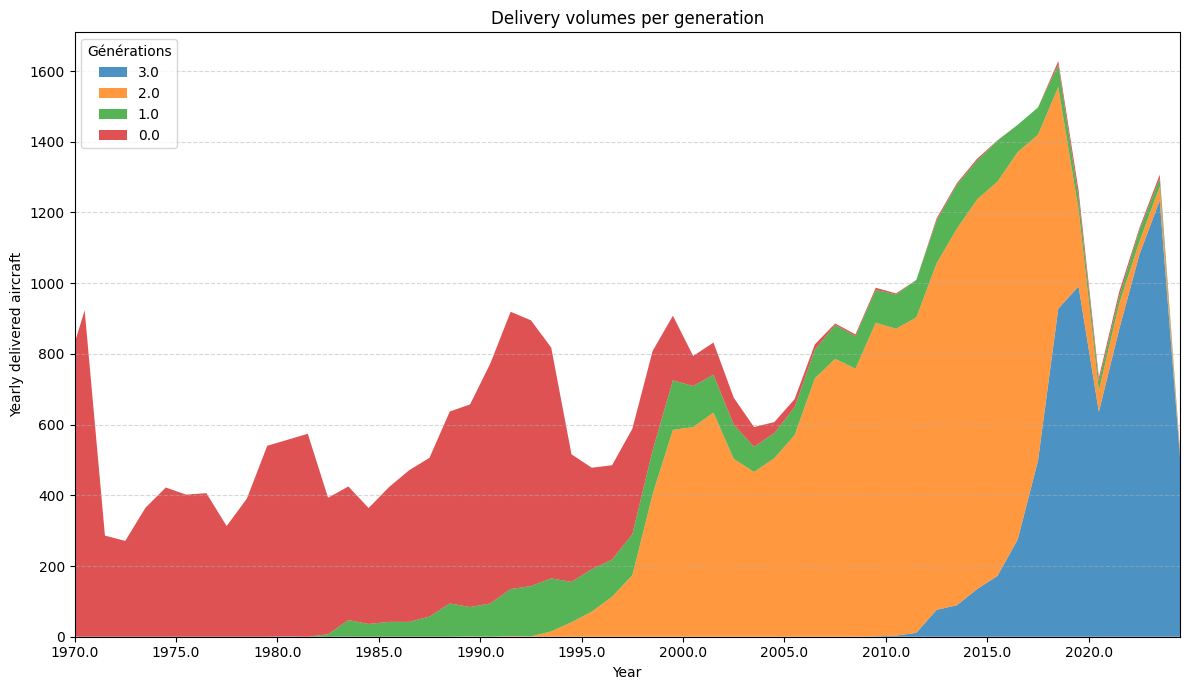

In [59]:
fleet_analysis.visu_prod(db_selec, reso = 1)

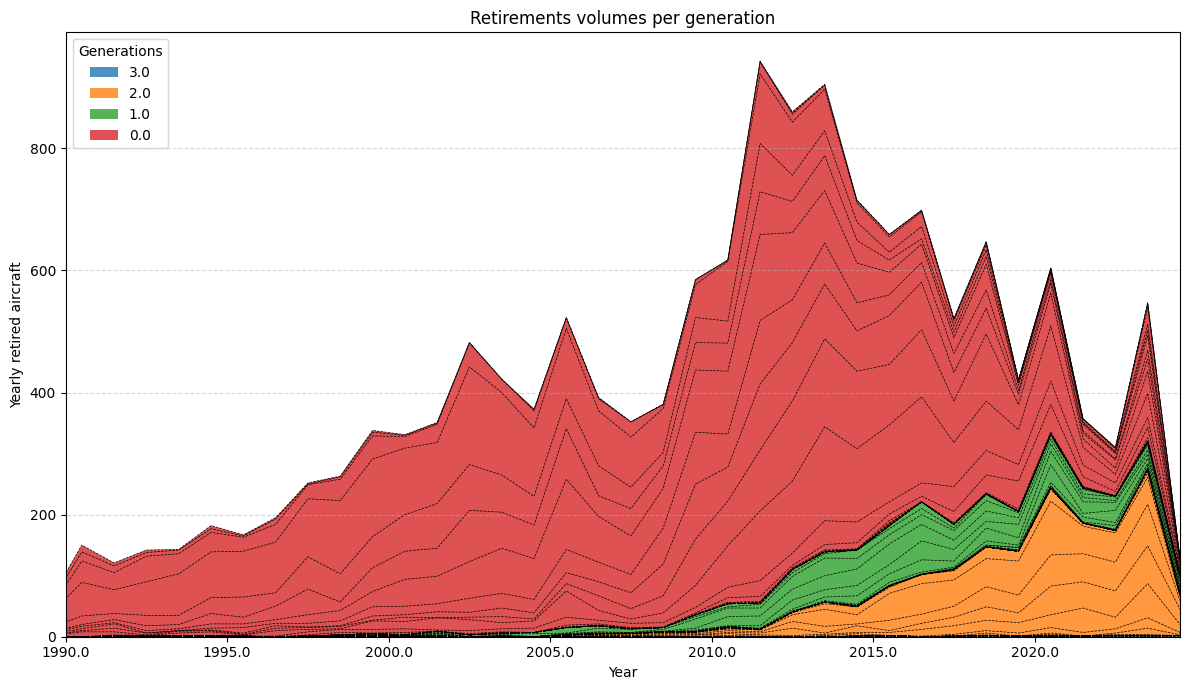

In [87]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

# Assignment model

In [12]:
y_min = 1990
y_max = 2024 #pour le modèle entraîné

ac_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y_min) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
for y in range(y_min+1, y_max+1):
    if y%5 == 0 :
        print(y)
    df = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
    traff_1 = pd.concat([traff_1, df], ignore_index=True)
traff_1 = pd.merge(traff_1, ac_ICAO_names[['AIRCRAFT_TYPE', 'ICAO_Code']], on = ['AIRCRAFT_TYPE'])

traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights',
                          'AIRCRAFT_TYPE': 'Aircraft Type','ICAO_Code':'Aircraft Type Name', 'UNIQUE_CARRIER' : 'Aircraft Operator','UNIQUE_CARRIER_NAME':'Aircraft Operator Name', 'SEATS': 'Seats'}, inplace = True)  
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1['DISTANCE'] = traff_1['DISTANCE']*1.852

print('a automatiser dans le module maybe, 1')
# distance_conn = (
#     traff_1.groupby(['ADEP', 'ADES','Period'])
#     .apply(lambda x: (x['Seats'] * x['DISTANCE']).sum() / x['Seats'].sum())
#     .reset_index()
#     .rename(columns={0: 'Distance_conn (km)'})
# )
distance_conn = (pd.concat([g['Seats'].sum().rename('Seats_sum'),
            (traff_1['Seats'] * traff_1['DISTANCE'])
                .groupby([traff_1['ADEP'], traff_1['ADES'], traff_1['Period']])
                .sum()
                .rename('SeatsDist_sum') ],axis=1)
    .assign(**{'Distance_conn (km)': lambda df: df['SeatsDist_sum'] / df['Seats_sum']})
    .reset_index()[['ADEP', 'ADES', 'Period', 'Distance_conn (km)']])

print('2')
seats_conn_p = (
    traff_1.groupby(['ADEP', 'ADES','Period'])['Seats']
    .sum()
    .reset_index()
    .rename(columns={'Seats': 'Seats_conn_p'})
)
print('synthesis...')
traff_1 = pd.merge(
    traff_1,
    distance_conn,
    on=['ADEP', 'ADES','Period'],
    how='left'
)
traff_1 = pd.merge(
    traff_1,
    seats_conn_p,
    on=['ADEP', 'ADES','Period'],
    how='left'
)

traff_1.drop(columns=['PASSENGERS', 'DISTANCE'], inplace = True)
traff_1['ASK_conn_p'] = traff_1['Seats_conn_p']*traff_1['Distance_conn (km)']
traff_1['ASK'] = traff_1['Seats']*traff_1['Distance_conn (km)']
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
print('ok')

1995
2000
2005
2010
2015
2020
a automatiser dans le module maybe, 1
2
synthesis...
ok


In [3]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')
traff_2.drop(columns=['Unnamed: 0','Siege_ADES', 'Siege_ADEP', 'Siege'], inplace = True)
traff_2['mean_distance'] = traff_2['mean_distance']*1.852
traff_2.rename(columns ={'AC Type':'Aircraft Type', 'AC Operator':'Aircraft Operator', 'echantillon':'Period', 
                         'Taille_f':'Seats', 'tau':'Weight', 'mean_distance':'Distance_conn (km)'}, inplace = True)
seats_conn_p = (
    traff_2.groupby(['ADEP', 'ADES','Period'])['Seats']
    .sum()
    .reset_index()
    .rename(columns={'Seats': 'Seats_conn_p'})
)
traff_2 = pd.merge(
    traff_2,
    seats_conn_p,
    on=['ADEP', 'ADES','Period'],
    how='left'
)

traff_2['Seats_conn_p'] = traff_2['Seats_conn_p']*12
traff_2['ADEP Name']=traff_2['ADEP']
traff_2['ADES Name']=traff_2['ADES']
traff_2['Aircraft Type Name']= traff_2['Aircraft Type']
traff_2['Aircraft Operator Name']=traff_2['Aircraft Operator']
traff_2['ASK'] = traff_2['Seats'] * traff_2['Distance_conn (km)']
traff_2['ASK_conn_p'] = traff_2['Seats_conn_p'] * traff_2['Distance_conn (km)']

In [1]:
print('ajouter la possibilite de fusionner les 2?, dans ce cas ajouter les poids sur bts aussi ?')

ajouter eurocontrol et la possibilite de fusionner les 2


In [122]:
show(ac_ICAO_names)

Loading ITables v2.6.2 from the internet... (need help?)


## Data visualisation

In [16]:
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([2024])], name_fig = 'market_bts_2024',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [0.8e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], n_market = 15, period_duration = 1, weight = False)

In [139]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([1990,1991])], [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [0.8e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], vmax = 0.5, period_duration = 1)

In [140]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'test_market_Type',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format='video')

Color choice...
Coloriage trouvé : {626: 0, 622: 1, 694: 2, 819: 3, 655: 4, 627: 5, 619: 6, 614: 7, 698: 8, 612: 9, 696: 10, 817: 11, 625: 12, 699: 11, 637: 12, 715: 13, 620: 14, 732: 15, 873: 16, 624: 13, 882: 14, 640: 9, 740: 17, 616: 18, 687: 15, 887: 16, 816: 7, 730: 8, 617: 19, 629: 17, 675: 19, 760: 5, 888: 6, 889: 13, 634: 18, 673: 4, 638: 17, 359: 18, 693: 10, 631: 15, 722: 3, 691: 16, 721: 17, 838: 19, 765: 18, 608: 14, 690: 2, 733: 17, 710: 16, 697: 10, 874: 14, 839: 1}
0.0%
8.571428571428571%
17.142857142857142%
25.714285714285715%
34.285714285714285%
42.857142857142854%
51.42857142857143%
60.0%
68.57142857142857%
77.14285714285714%
85.71428571428571%
94.28571428571429%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [137]:
assignment_analysis.dynamic_assign_vis(traff_1, [715], [1990,1991,1992,1993,1994], format = 'gif', video_name = '715_assign', market = 'Aircraft Type',
                                       observation = 'ASK', dist_limits = [1.5e2, 1.9e4], capac_limits = [2e3, 6e6],
                                      frame_s = 2, color = 'pink', reso = 400, smooth_param = 0.05, period_duration = 1, vmax = 0.5)

0.0%
60.0%


## Model training

# Productivité des avions

In [47]:
individual_stops = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_ind_anal.csv')
individual_stops.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Taille_f', 
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
individual_stops.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                 'ADES_nf': 'ADES +1', 'ADEP_nf' : 'ADEP +1', 'ADEP_pf': 'ADEP -1', 'ADES_pf': 'ADES -1',
                                'echantillon':'Period','time_delta': 'Real Flight Duration', 'time_delta2':'Planned Flight Duration',
                                'time_delta_nf': 'Real Flight Duration +1', 'time_delta2_nf':'Planned Flight Duration +1',
                                 'time_delta_pf': 'Real Flight Duration -1', 'time_delta2_pf':'Planned Flight Duration -1',
                                 'delta_flights' : 'Ground Time', 'delta_pre_flights' : 'Ground Time -1'}, inplace = True)

In [103]:
flights_streaks = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_long_anal.csv')
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['FILED OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['FILED ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['ACTUAL OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['ACTUAL ARRIVAL TIME'], utc=True).dt.tz_localize(None)

## Data visualisation individual stops

In [98]:
productivity_analysis.GT_density(individual_stops, name_fig = 'GT_density_2',sigma = 0.005, reso = 1000)

In [101]:
productivity_analysis.TATs_matrix(individual_stops, name_fig= 'Full_df', reso = 1000, sigma = 0.02)

5.4% are not b&f flights


## Data visualisation flight streaks

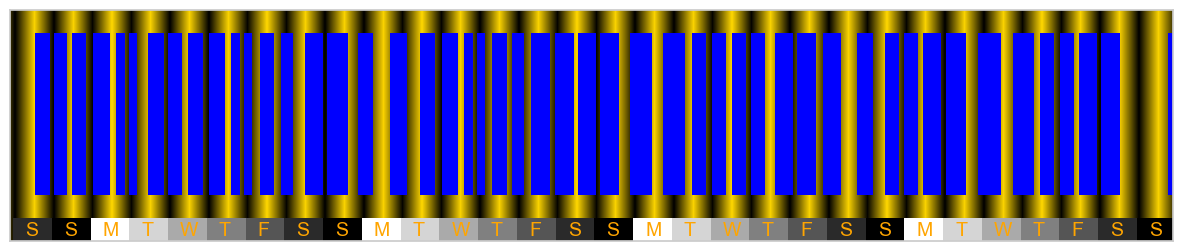

In [113]:
aircraft_ex = flights_streaks[(flights_streaks['AC Registration']=='FGZNR')&(flights_streaks['echantillon']==17)] #B77w
productivity_analysis.visu(aircraft_ex, titre = 'B77W', visu = True, x_min = None)


## Model training